# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [ ]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN
symbol = 'INFY_NS.csv'
df = pd.read_csv('data/raw/INFY_NS.csv',index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.sort_index()
df.columns = [col.lower() for col in df.columns]
df['volume'].fillna(0)
display(df)


In [ ]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [ ]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
#return_1     = ...
#return_5     = ...
#log_return_1 = ...

df['return_1']     = df['close'].pct_change(1)
df['return_5']     = df['close'].pct_change(5)
df['log_return_1'] = np.log(df['close']/df['close'].shift(1))
display(df)

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [ ]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = df['close'].rolling(20).mean()
df['sma_50']      = df['close'].rolling(50).mean()
df['sma_200']     = df['close'].rolling(200).mean()
df['sma_ratio_20'] = df['close'] / df['close'].rolling(20).mean()
df['sma_ratio_50'] = df['close'] / df['close'].rolling(50).mean()
display(df)

In [ ]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.loc[df.index >= df.index.max() - pd.DateOffset(years=2)]
cross  = recent['sma_50'] - recent['sma_200']
golden = (cross>0) & (cross.shift(1) <= 0)
death  = (cross<0) & (cross.shift(1) >= 0)
# Plot Graph
plt.plot(recent['close'],label='close')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['sma_50'],label='SMA_50')
plt.grid(True)
for a in recent[golden].index:
    plt.axvline(a,color='gold')
for a in recent[death].index:
    plt.axvline(a,color='black')
plt.title('CLOSE AND SMA_20 AND SMA_50')
plt.tight_layout()
plt.legend()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [ ]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20
df['ema_12']       = df['close']*(2/13) + df['close'].shift(1)*(1-2/13)
df['ema_20']       = df['close']*(2/21) + df['close'].shift(1)*(1-2/21)
df['ema_26']       = df['close']*(2/27) + df['close'].shift(1)*(1-2/27)
df['ema_ratio_20'] = df['close'] / df['ema_20'] -1
display(df)

In [ ]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
plt.plot(recent['close'],label='CLOSE')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['ema_20'],label='EMA_20')
display(recent)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [ ]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

delta    = df['close'].diff()
#print(delta)
gain     = delta.clip(lower=0)
#print(gain)
loss     = -delta.clip(upper=0)
#print(loss)
n = 14
avg_gain = gain.ewm(com=n-1,adjust=False).mean()
avg_loss = loss.ewm(com=n-1,adjust=False).mean()
rs       = avg_gain / avg_loss
df['rsi_14'] = 100 - 100/(1+rs)
df['rsi_14'] = df['rsi_14']/100

In [ ]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]

close = recent['close']
rsi = recent['rsi_14']

fig,ax = plt.subplots(2,1,sharex=True)

ax[0].plot(recent.index,close,label='CLOSE')
ax[0].legend()

ax[1].plot(recent.index,rsi,label='RSI')

ax[1].axhline(0.7,linestyle='--',color='black')
ax[1].axhline(0.3,linestyle='--',color='black')

ax[1].fill_between(
    recent.index,rsi,0.7,where=(rsi>=0.7),color='red',alpha=0.2,label='OVERBROUGHT'
)

ax[1].fill_between(
    recent.index,rsi, 0.3,where=(rsi <= 0.3),color='green',alpha=0.2,label='OVERSOLD'
)
plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [ ]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9,adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']
df

In [ ]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
close = recent['close']
macd = recent['macd']
signal = recent['macd_signal']
hist = recent['macd_hist']
colors = np.where(hist >= 0,'green','red')

fig,axis = plt.subplots(3,1,sharex=True)
axis[0].plot(recent.index,close,label='CLOSE')
axis[0].legend()

axis[1].plot(recent.index,macd,label='MACD')
axis[1].plot(recent.index,signal,label='SIGNAL')
axis[1].legend()

axis[2].bar(recent.index,hist,color=colors)
axis[2].axhline(0, linestyle='--')

plt.tight_layout()
plt.show()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [ ]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = df['close'].rolling(20).std()
df['bb_upper'] = df['sma_20'] + 2 * rolling_std
df['bb_lower'] = df['sma_20'] - 2 * rolling_std 
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['close']
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
df['bb_pct_b'] = df['bb_pct_b'].clip(0,1) 
# clip to [0, 1] optional but useful

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [ ]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = (df['close'] - df['close'].shift(5)) / df['close'].shift(5) * 100
df['roc_10'] = (df['close'] - df['close'].shift(10)) / df['close'].shift(10) * 100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [ ]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = df['close'].shift(1)
tr1 = df['high'] - df['low']
tr2 = (df['high'] - prev_close).abs()
tr3 = (df['low'] - prev_close).abs()
true_range = pd.concat([tr1,tr2,tr3],axis=1).max(axis=1)
df['atr_14']    = true_range.ewm(com=13,adjust=False).mean()
df['atr_ratio'] = df['atr_14'] / df['close']
display(df)

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [130]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].rolling(14).min()
highest_high = df['high'].rolling(14).max()
df['stoch_k'] = (df['close'] - lowest_low) / (highest_high - lowest_low)
df['stoch_d'] = df['stoch_k'].rolling(3).mean()

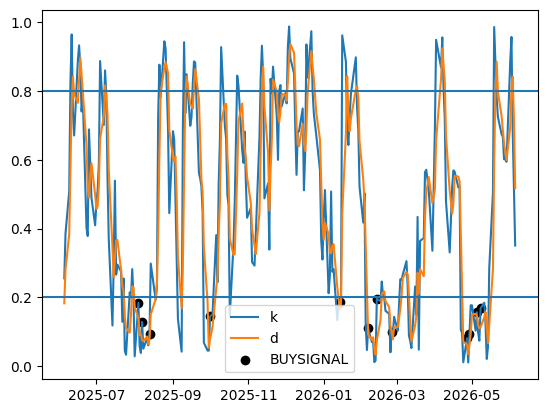

In [131]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
k = recent['stoch_k']
d = recent['stoch_d']
plt.plot(recent.index,k,label='k')
plt.plot(recent.index,d,label='d')
plt.axhline(0.8)
plt.axhline(0.2)

buy_signal = ((k > d) & (k.shift(1) < d.shift(1)) & (k < 0.2))
plt.scatter(recent.index[buy_signal],k[buy_signal],label='BUYSIGNAL',color='black')
plt.legend()
plt.show()


## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [132]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(close.diff())
obv_chan = direction * df['volume']
df['obv']       = obv_chan.cumsum()
df['obv_change']= (df['obv'].diff()) / df['obv'].shift(1).abs()
df

,adj_close,close,high,low,open,volume,symbol,future_return,target_direction,vwap,...,macd,macd_signal,macd_hist,bb_upper,bb_lower,bb_width,bb_pct_b,return_1,return_5,log_return_1
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,367.770752,493.600006,495.500000,489.225006,492.237488,2002764,INFY.NS,0.019652,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,374.998077,503.299988,504.762512,493.000000,493.000000,6778320,INFY.NS,-0.008593,0,NaN,...,0.773788,0.773788,0.000000,NaN,NaN,NaN,NaN,0.019652,NaN,0.019461
2015-01-05,371.775604,498.975006,507.500000,494.375000,502.475006,9937024,INFY.NS,-0.020893,0,NaN,...,-0.345013,0.550028,-0.895040,NaN,NaN,NaN,NaN,-0.008593,NaN,-0.008630
2015-01-06,364.008179,488.549988,496.250000,483.524994,495.000000,9667316,INFY.NS,0.004785,1,NaN,...,-0.831625,0.273697,-1.105322,NaN,NaN,NaN,NaN,-0.020893,NaN,-0.021114
2015-01-07,365.749817,490.887512,493.687500,487.500000,491.250000,7249916,INFY.NS,0.005042,1,NaN,...,0.186469,0.256251,-0.069782,NaN,NaN,NaN,NaN,0.004785,NaN,0.004773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,1202.500000,1202.500000,1217.000000,1173.699951,1175.000000,19439331,INFY.NS,0.056798,1,1166.092791,...,3.318517,0.613156,2.705361,1216.736855,1108.243126,0.090223,0.868777,0.035834,0.029097,0.035207
2026-06-02,1270.800049,1270.800049,1278.900024,1232.500000,1232.500000,36032600,INFY.NS,-0.037929,0,1176.609748,...,5.448437,1.580212,3.868225,1239.724346,1094.525642,0.114258,1.000000,0.056798,0.088293,0.055244
2026-06-03,1222.599976,1222.599976,1249.900024,1216.000000,1242.099976,18534303,INFY.NS,-0.017422,0,1179.683555,...,-3.845020,0.495166,-4.340186,1246.616875,1093.173115,0.125506,0.843481,-0.037929,0.054056,-0.038667


## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [ ]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (df['high'] + df['low'] + df['close']) / 3
tp_vol          = typical_price * df['volume']
df['vwap']       = tp_vol.rolling(20).sum() / df['volume'].rolling(20).sum()
df['vwap_ratio'] = df['close'] / df['vwap'] - 1
df.columns

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [ ]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio','future_return','target_direction'
]

In [ ]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = df['close'].shift(-1) / df['close'] - 1
df['target_direction'] = (df['future_return'] > 0).astype(int)

required = FEATURE_COLUMNS
df       = df.replace([np.inf,-np.inf],np.nan)
df_clean = df.dropna(subset=required).copy()
df_clean = df_clean.reset_index()
out_path = PROCESSED_DIR/f'{safe_symbol(symbol)}_features.csv'
df_clean.to_csv(out_path)
print(f'SAVED {safe_symbol(symbol)}.csv')
display(df_clean[required].describe().round(4))

In [ ]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in ...:
    sym = ...
    try:
        raw       = ...
        # ... compute all indicators on raw ...
        processed = ...
        # ... save to PROCESSED_DIR ...
        summary.append({...})
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

---
